## Drug Type and Presence encode information about drug-cognition interaction in Major Depression and Bipolar Disoder: A Multiple Correspondence Analysis approach

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import prince

### Load data (farmaci a T0 e test a T1)

In [3]:
import pandas as pd

# Define columns to keep
farmaci_da = "Benzodiazepine"
farmaci_a = "Ariprazolo(6)"
test_da = "MMSE_T1"
test_a = "FAS_t1"
test_temp_da = "MMSE_T0"
test_temp_a = "FAS_T0"

# Load the data using pandas
t0 = pd.read_csv("T0.csv", sep=",", encoding="utf-8")
t1 = pd.read_csv("T1.csv", sep=",", encoding="utf-8")

# Filter both t0 and t1 to include only rows with matching "Nome" values
common_names = t0["Nome"].isin(t1["Nome"])
t0 = t0[common_names]
t1 = t1[t1["Nome"].isin(t0["Nome"])]

# Reset the index to align rows if needed
t0 = t0.reset_index(drop=True)
t1 = t1.reset_index(drop=True)

# Split patients for diagnosis, 1 Depressed, 2 Bipolar;
t0_1 = t0[t0["Diagnosi"] == 1]
t0_2 = t0[t0["Diagnosi"] == 2]
t1_1 = t1[t1["diagnosi_T1"] == 1]
t1_2 = t1[t1["diagnosi_T1"] == 2]

# Select the specific column ranges;
t0_1 = t0_1.loc[:, farmaci_da : farmaci_a]
t0_2 = t0_2.loc[:, farmaci_da : farmaci_a]
t1_1 = t1_1.loc[:, test_da : test_a]
t1_2 = t1_2.loc[:, test_da : test_a]

# Get differences between test at t0 and t1 (tdiff)
temp_1 = pd.read_csv("T0.csv", sep=",", encoding="utf-8")
temp_1 = temp_1[temp_1["Diagnosi"] == 1]
temp_1 = temp_1.loc[:, test_temp_da : test_temp_a]
columns_1 = [col.rsplit("_", 1)[0] for col in temp_1.columns]
tdiff_1 = temp_1.to_numpy() - t1_1.to_numpy()

temp_2 = pd.read_csv("T0.csv", sep=",", encoding="utf-8")
temp_2 = temp_2[temp_2["Diagnosi"] == 2]
temp_2 = temp_2.loc[:, test_temp_da : test_temp_a]
columns_2 = [col.rsplit("_", 1)[0] for col in temp_2.columns]
tdiff_2 = temp_2.to_numpy() - t1_2.to_numpy()

### MCA, Diagnosi 1 (Major Depression)

/tmp/ipykernel_14709/379758343.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_contributors.index, y=top_contributors['Contribution'], ax=ax, palette='viridis')
/tmp/ipykernel_14709/379758343.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


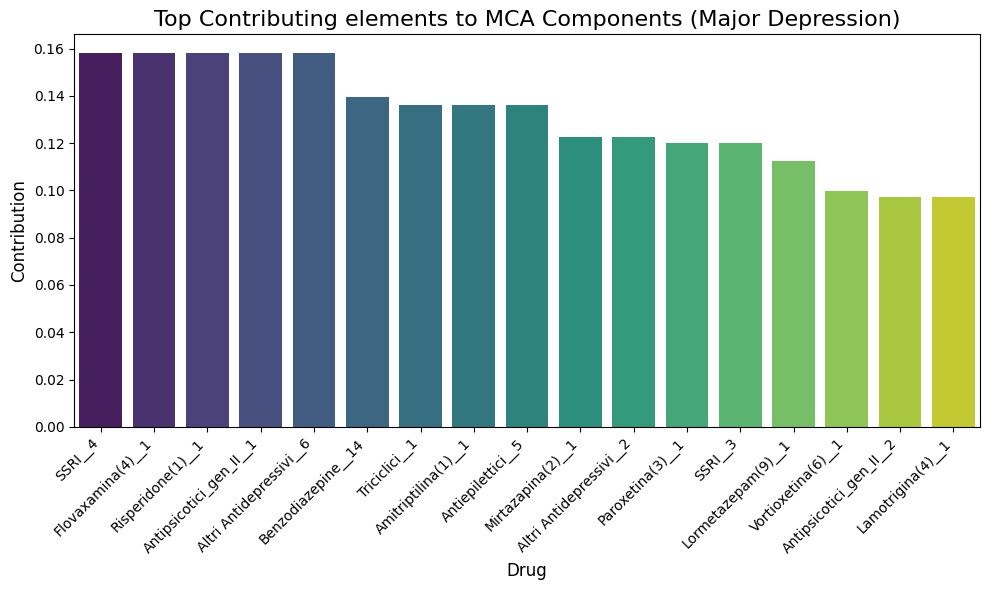

/tmp/ipykernel_14709/379758343.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_contributors[component_name],
/tmp/ipykernel_14709/379758343.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_contributors[component_name],
/tmp/ipykernel_14709/379758343.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_contributors[component_name],
/tmp/ipykernel_14709/379758343.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `le

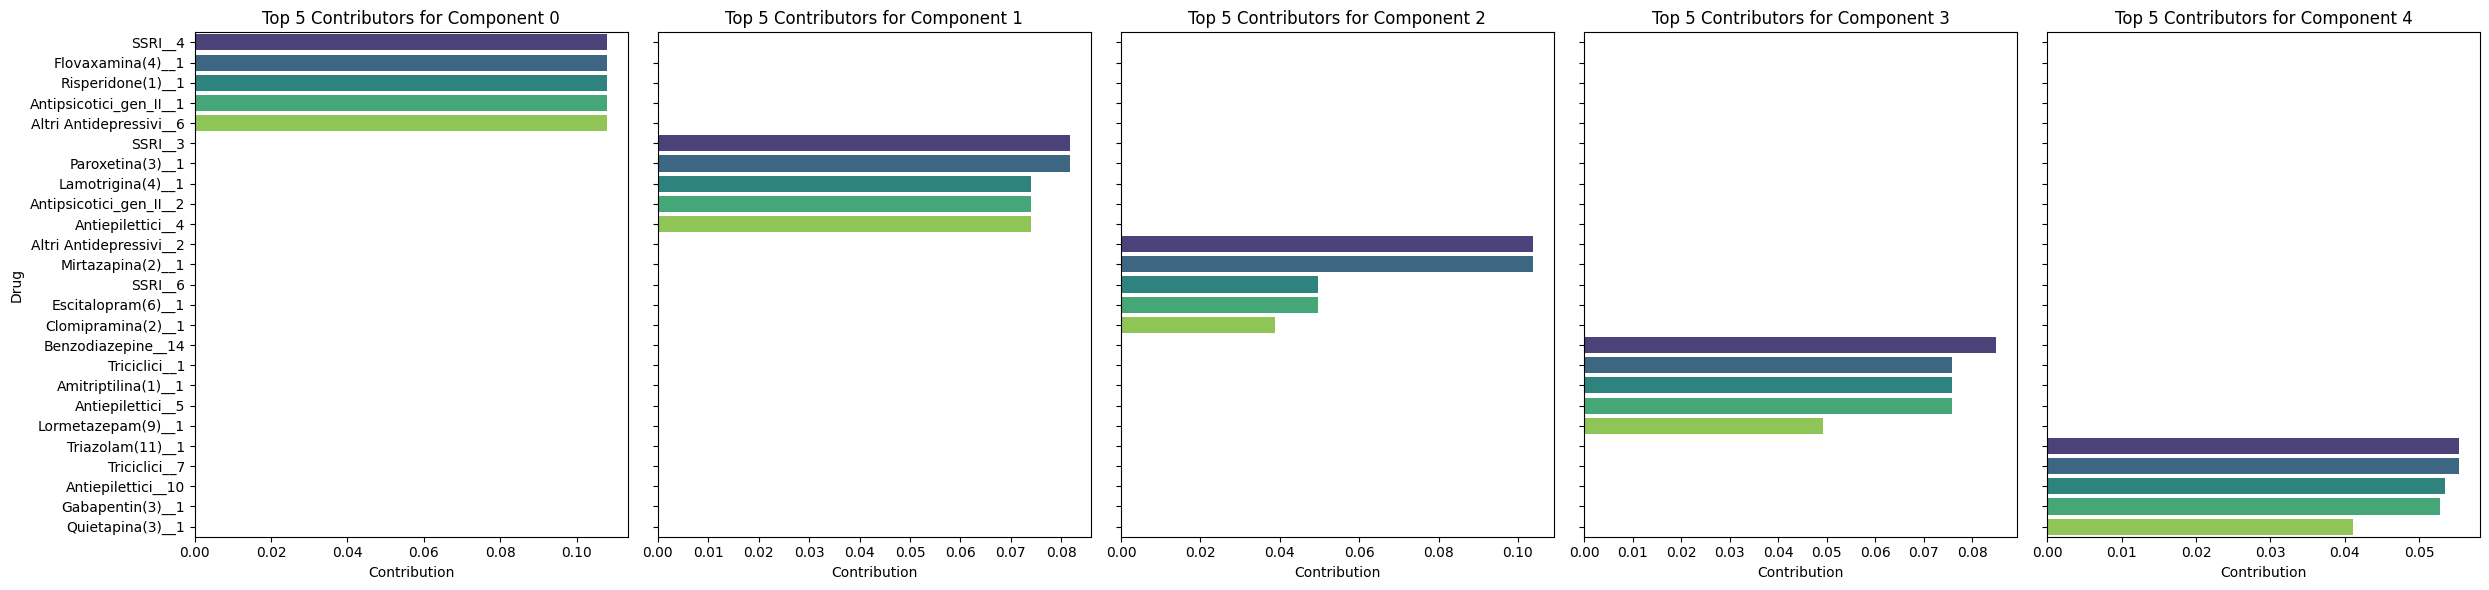

In [8]:
from sklearn.preprocessing import StandardScaler

# Fit the MCA model
mca = prince.MCA(
    n_components=5,
    n_iter=1000,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=342423423
)
mca = mca.fit(t0_1)

# Standardize the values of t1 (z-score normalization)
scaler = StandardScaler()

# Step 1: Extract MCA components from the fitted model
mca_components = mca.transform(t0_1)  # Extract components
mca_components_df = pd.DataFrame(mca_components)
mca_components_df.columns = [f"Component {i}" for i in range(mca_components.shape[1])]

# Ensure the DataFrame is aligned with t1 (reset the indices to match)
mca_components_df.reset_index(drop=True, inplace=True)

# Extract the contributions for each component and sort them
contribution = mca.column_contributions_
contribution['Contribution'] = contribution.sum(axis=1)

# Sort the DataFrame by 'Contribution' in descending order
contribution_sorted = contribution.sort_values(by='Contribution', ascending=False)

# Plotting the contributions of the top 10 drugs for each component
num_top_drugs = 17  # You can adjust this value based on how many drugs you want to show
top_contributors = contribution_sorted.head(num_top_drugs)

# Create a bar plot for the top contributing drugs
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_contributors.index, y=top_contributors['Contribution'], ax=ax, palette='viridis')

ax.set_title('Top Contributing elements to MCA Components (Major Depression)', fontsize=16)
ax.set_xlabel('Drug', fontsize=12)
ax.set_ylabel('Contribution', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Extract the contributions for each component
contribution = mca.column_contributions_

# Set the number of top contributors to display for each component
num_top_contributors = 5  # You can adjust this value based on how many drugs you want to show for each component

# Plotting the top contributors for each MCA component
num_components = mca.n_components  # Number of components to show
fig, axes = plt.subplots(1, num_components, figsize=(5 * num_components, 6), sharey=True)

# Loop through each component to plot the top contributors
for i in range(num_components):
    # Get the actual column name for the component (as integer)
    component_name = i  # The columns are numbered as 0, 1, 2, 3, 4...
    
    # Get the top contributors for the current component
    top_contributors = contribution.sort_values(by=component_name, ascending=False).head(num_top_contributors)
    
    # Create a horizontal bar plot for the top contributors
    sns.barplot(x=top_contributors[component_name], 
                y=top_contributors.index, 
                ax=axes[i], 
                palette='viridis')
    
    # Add title and labels to each subplot
    axes[i].set_title(f'Top {num_top_contributors} Contributors for Component {component_name}', fontsize=12)
    axes[i].set_xlabel('Contribution', fontsize=10)
    axes[i].set_ylabel('Drug', fontsize=10)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

### MCA, Diagnosi 2 (Bipolar I)

/tmp/ipykernel_14709/2083994030.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_contributors.index, y=top_contributors['Contribution'], ax=ax, palette='viridis')
/tmp/ipykernel_14709/2083994030.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


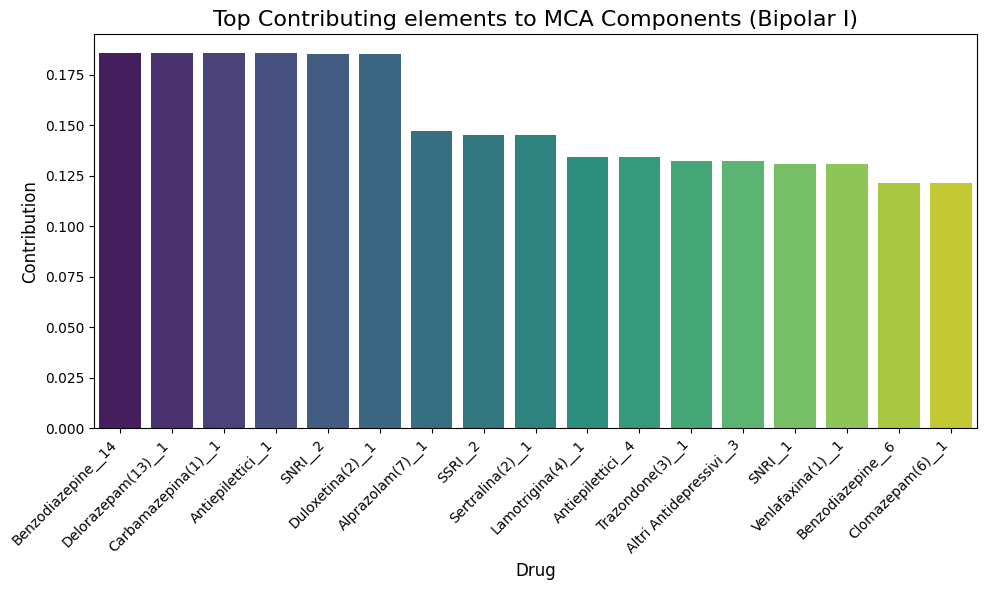

/tmp/ipykernel_14709/2083994030.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_contributors[component_name],
/tmp/ipykernel_14709/2083994030.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_contributors[component_name],
/tmp/ipykernel_14709/2083994030.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_contributors[component_name],
/tmp/ipykernel_14709/2083994030.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set

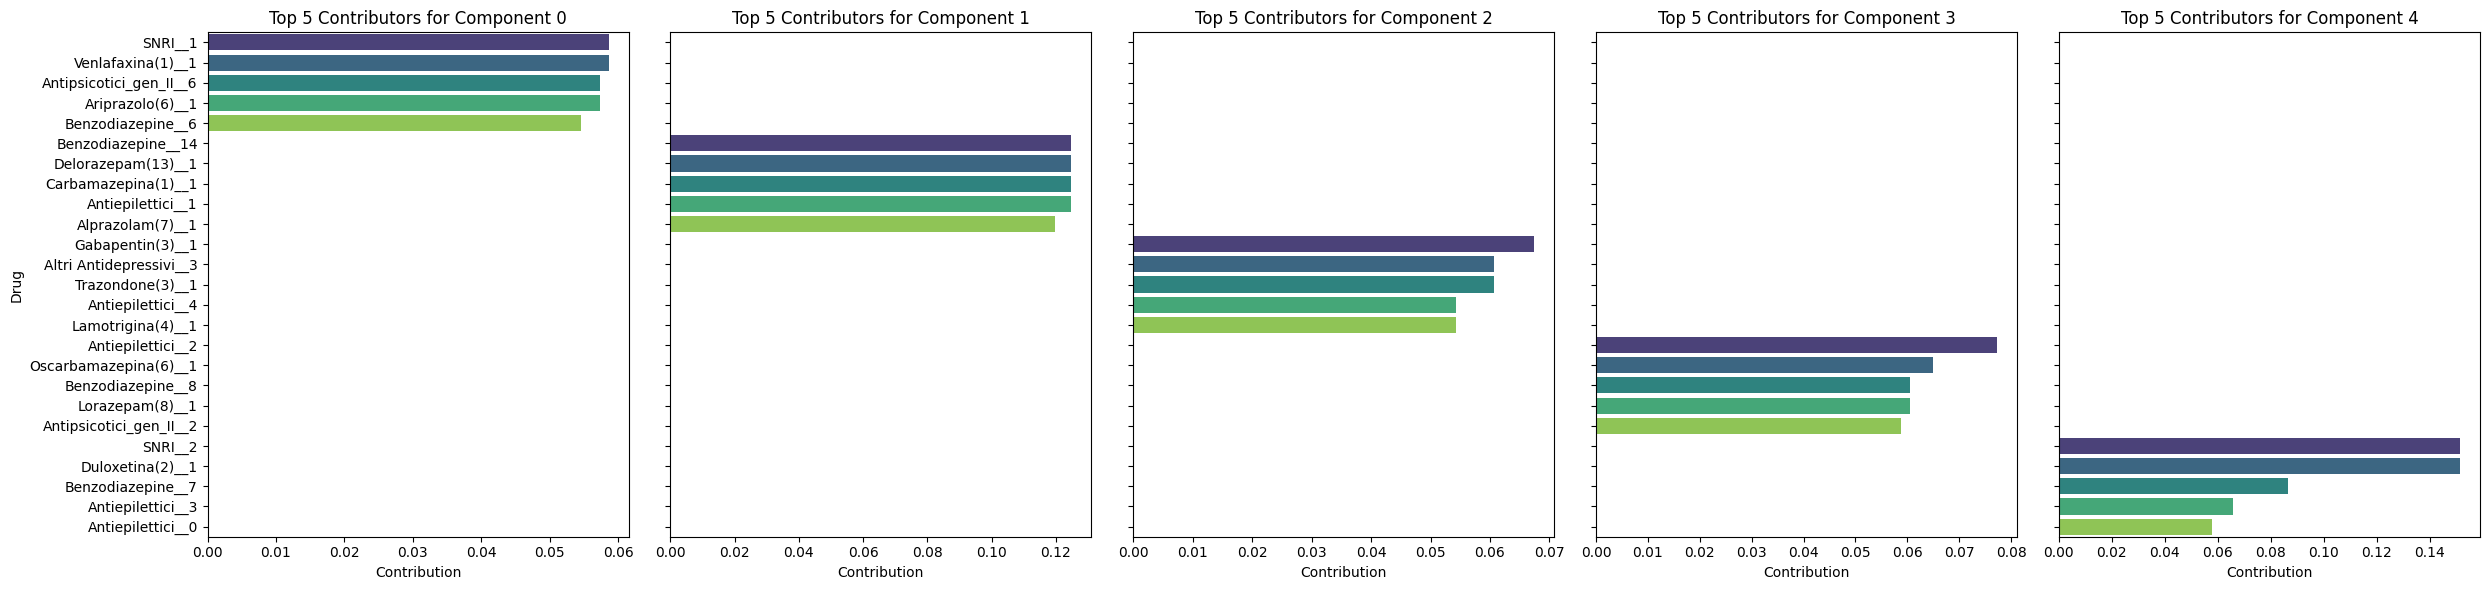

In [9]:
# Fit the MCA model
mca = prince.MCA(
    n_components=5,
    n_iter=1000,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=342423423
)
mca = mca.fit(t0_2)

# Standardize the values of t1 (z-score normalization)
scaler = StandardScaler()

# Step 1: Extract MCA components from the fitted model
mca_components = mca.transform(t0_2)  # Extract components
mca_components_df = pd.DataFrame(mca_components)
mca_components_df.columns = [f"Component {i}" for i in range(mca_components.shape[1])]

# Ensure the DataFrame is aligned with t1 (reset the indices to match)
mca_components_df.reset_index(drop=True, inplace=True)

# Extract the contributions for each component and sort them
contribution = mca.column_contributions_
contribution['Contribution'] = contribution.sum(axis=1)

# Sort the DataFrame by 'Contribution' in descending order
contribution_sorted = contribution.sort_values(by='Contribution', ascending=False)

# Plotting the contributions of the top 10 drugs for each component
num_top_drugs = 17  # You can adjust this value based on how many drugs you want to show
top_contributors = contribution_sorted.head(num_top_drugs)

# Create a bar plot for the top contributing drugs
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_contributors.index, y=top_contributors['Contribution'], ax=ax, palette='viridis')

ax.set_title('Top Contributing elements to MCA Components (Bipolar I)', fontsize=16)
ax.set_xlabel('Drug', fontsize=12)
ax.set_ylabel('Contribution', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Extract the contributions for each component
contribution = mca.column_contributions_

# Set the number of top contributors to display for each component
num_top_contributors = 5  # You can adjust this value based on how many drugs you want to show for each component

# Plotting the top contributors for each MCA component
num_components = mca.n_components  # Number of components to show
fig, axes = plt.subplots(1, num_components, figsize=(5 * num_components, 6), sharey=True)

# Loop through each component to plot the top contributors
for i in range(num_components):
    # Get the actual column name for the component (as integer)
    component_name = i  # The columns are numbered as 0, 1, 2, 3, 4...
    
    # Get the top contributors for the current component
    top_contributors = contribution.sort_values(by=component_name, ascending=False).head(num_top_contributors)
    
    # Create a horizontal bar plot for the top contributors
    sns.barplot(x=top_contributors[component_name], 
                y=top_contributors.index, 
                ax=axes[i], 
                palette='viridis')
    
    # Add title and labels to each subplot
    axes[i].set_title(f'Top {num_top_contributors} Contributors for Component {component_name}', fontsize=12)
    axes[i].set_xlabel('Contribution', fontsize=10)
    axes[i].set_ylabel('Drug', fontsize=10)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

### Decoding drug-cognition interactions through MCA and predictive modelling.

Running a Ridge Regression model with Nested-Cross Validation (Robust) - MAJOR DEPRESSION

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
import prince

# Prepare variables for our predictive model
X_1 = t0_1
y_1 = pd.DataFrame(tdiff_1, columns=columns_1)
adjust_param = 1e-15

# Initialize storage for best models, coefficients, and MCA contributions
best_models_per_target = {}
coefficients_per_target = {}
mca_contributions_per_target = {}

# Define the Ridge regression model
model = Ridge()

# Define the grid for searching the MCA components
param_grid = {
    'mca__n_components': [5, 15, 30],
    'model__alpha': [0.1, 1, 10]
}

outer_cv = KFold(n_splits=5, shuffle=True, random_state=44852523)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=73491241)

# Initialize storage for MAE and confidence intervals
mae_scores = []
mae_ci_lower = []
mae_ci_upper = []
target_names = []

# Loop through all targets (columns in y_1)
for idx, target in enumerate(y_1.columns):
    print(f"Processing Target {idx}: {target}")
    y_target = y_1[target]
    
    # Initialize variables to store the best model and evaluation scores
    best_model_for_target = None
    best_score = np.inf  # We will minimize the MSE
    
    # Storage for test scores for each fold
    test_scores_mae = []
    test_scores_r2 = []
    
    # Outer loop (for cross-validation)
    for train_idx, test_idx in outer_cv.split(X_1, y_target):
        X_train, X_test = X_1.iloc[train_idx], X_1.iloc[test_idx]
        y_train, y_test = y_target.iloc[train_idx], y_target.iloc[test_idx]
        
        # Define the pipeline: MCA -> Ridge regression model
        pipeline = Pipeline([
            ('mca', prince.MCA(
                n_iter=5000,
                copy=True,
                check_input=True,
                engine='sklearn',
                random_state=283434922)),
            ('model', model)
        ])

        # Inner cross-validation loop using GridSearchCV to tune hyperparameters
        grid_search = GridSearchCV(pipeline, param_grid, cv=inner_cv, scoring='neg_mean_squared_error', n_jobs=4)

        # Perform grid search with cross-validation on the training set
        grid_search.fit(X_train, y_train)
        
        # Get the best model from the grid search
        best_fold_model = grid_search.best_estimator_

        # Evaluate the model on the test fold and store scores
        y_pred = best_fold_model.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = np.corrcoef(y_test, y_pred)[0][1]**2
        
        # Store the MAE for the current fold
        test_scores_mae.append(mae)
        test_scores_r2.append(r2)

        # Track the best model based on the lowest MSE
        if mae < best_score:
            best_score = mae
            best_model_for_target = best_fold_model
    
    # After all outer folds, store the best model for the current target
    best_models_per_target[target] = best_model_for_target

    # Extract the coefficients from the best model
    ridge_model = best_model_for_target.named_steps['model']
    coefficients_per_target[target] = ridge_model.coef_

    # Capture MCA column contributions (contributions of columns to components)
    mca = best_model_for_target.named_steps['mca']
    mca_contributions_per_target[target] = mca.column_contributions_

    # Compute the mean and confidence intervals for MAE across all folds
    mean_mae = np.mean(test_scores_mae)
    mean_r2 = np.mean(test_scores_r2)
    ci_lower = np.percentile(test_scores_mae, 2.5)  # 95% confidence interval lower bound
    ci_upper = np.percentile(test_scores_mae, 97.5)  # 95% confidence interval upper bound
    
    # Store the results for plotting
    mae_scores.append(mean_mae)
    mae_ci_lower.append(ci_lower)
    mae_ci_upper.append(ci_upper)
    target_names.append(target)

    print(f"{target}: R2: {mean_r2}, MAE: {mean_mae}")


Processing Target 0: MMSE
MMSE: R2: 0.25455837631590533, MAE: 3.67966989563089
Processing Target 1: MoCA
MoCA: R2: 0.2990141537995069, MAE: 2.5958759867323735
Processing Target 2: FAB
FAB: R2: 0.2516728940541525, MAE: 1.9524895937913527
Processing Target 3: SPAN_A
SPAN_A: R2: 0.14539747443872147, MAE: 0.992303920105974
Processing Target 4: SPAN_I
SPAN_I: R2: 0.0976007649512667, MAE: 1.1665320426264763
Processing Target 5: REY_I
REY_I: R2: 0.16099232397468458, MAE: 6.970260053020101
Processing Target 6: REY D C T0
REY D C T0: R2: 0.1526346709702595, MAE: 2.1353950213902744
Processing Target 7: HDRS
HDRS: R2: 0.20844012564253084, MAE: 6.606925853240204
Processing Target 8: BDI
BDI: R2: 0.2684243506907321, MAE: 10.991278563622934
Processing Target 9: Vocab
Vocab: R2: 0.2460432143702525, MAE: 1.5782624376978798
Processing Target 10: FAS
FAS: R2: 0.06848502663157428, MAE: 7.55181698294288


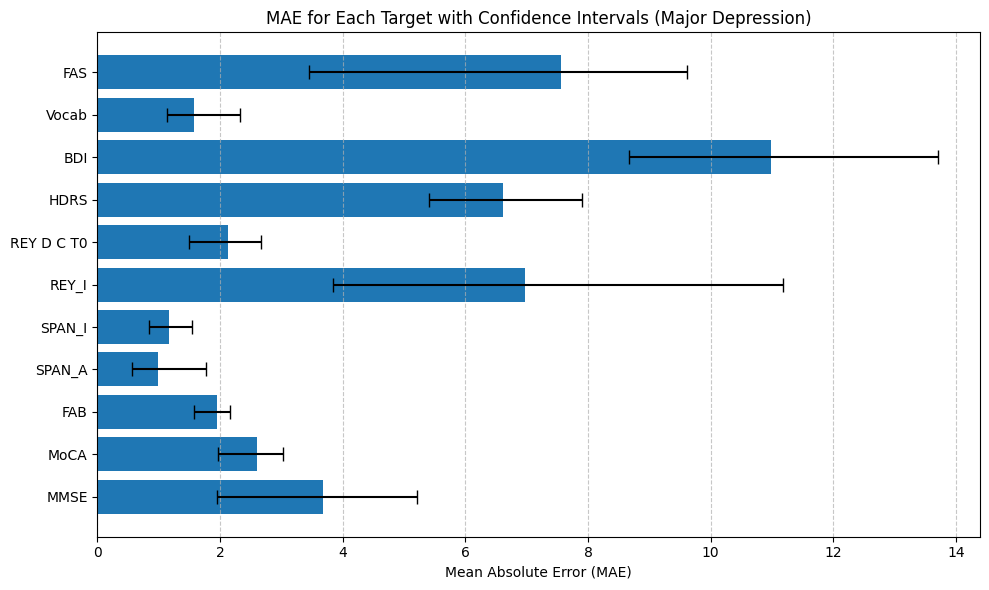

In [11]:
# Plotting the MAE with confidence intervals
plt.figure(figsize=(10, 6))
plt.barh(target_names, mae_scores, xerr=[np.array(mae_scores) - np.array(mae_ci_lower), np.array(mae_ci_upper) - np.array(mae_scores)], capsize=5)
plt.xlabel('Mean Absolute Error (MAE)')
plt.title('MAE for Each Target with Confidence Intervals (Major Depression)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [12]:
best_models_per_target # best overall model has 5 components and alpha = 10

{'MMSE': Pipeline(steps=[('mca',
                  MCA(n_components=5, n_iter=5000, random_state=283434922)),
                 ('model', Ridge(alpha=10))]),
 'MoCA': Pipeline(steps=[('mca',
                  MCA(n_components=5, n_iter=5000, random_state=283434922)),
                 ('model', Ridge(alpha=10))]),
 'FAB': Pipeline(steps=[('mca',
                  MCA(n_components=5, n_iter=5000, random_state=283434922)),
                 ('model', Ridge(alpha=1))]),
 'SPAN_A': Pipeline(steps=[('mca',
                  MCA(n_components=5, n_iter=5000, random_state=283434922)),
                 ('model', Ridge(alpha=1))]),
 'SPAN_I': Pipeline(steps=[('mca',
                  MCA(n_components=30, n_iter=5000, random_state=283434922)),
                 ('model', Ridge(alpha=10))]),
 'REY_I': Pipeline(steps=[('mca',
                  MCA(n_components=5, n_iter=5000, random_state=283434922)),
                 ('model', Ridge(alpha=10))]),
 'REY D C T0': Pipeline(steps=[('mca',
                

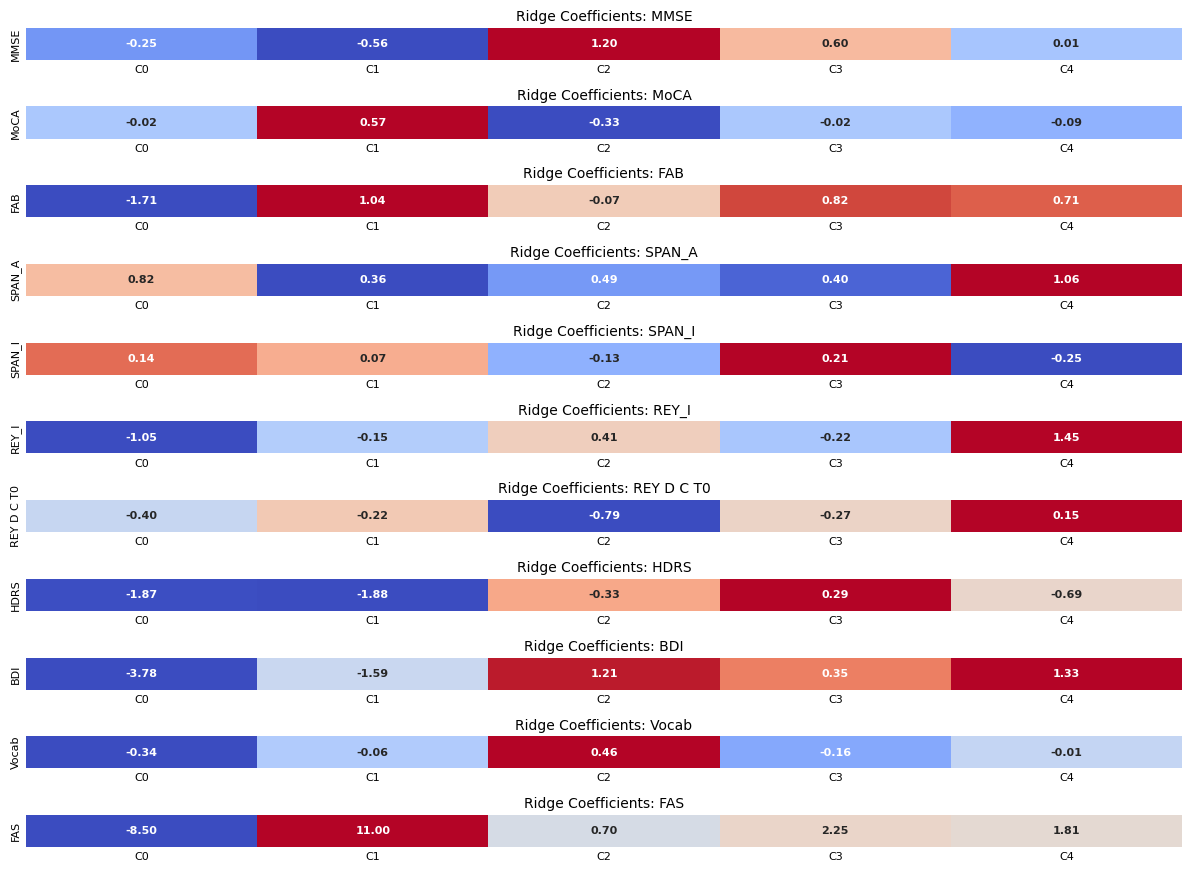

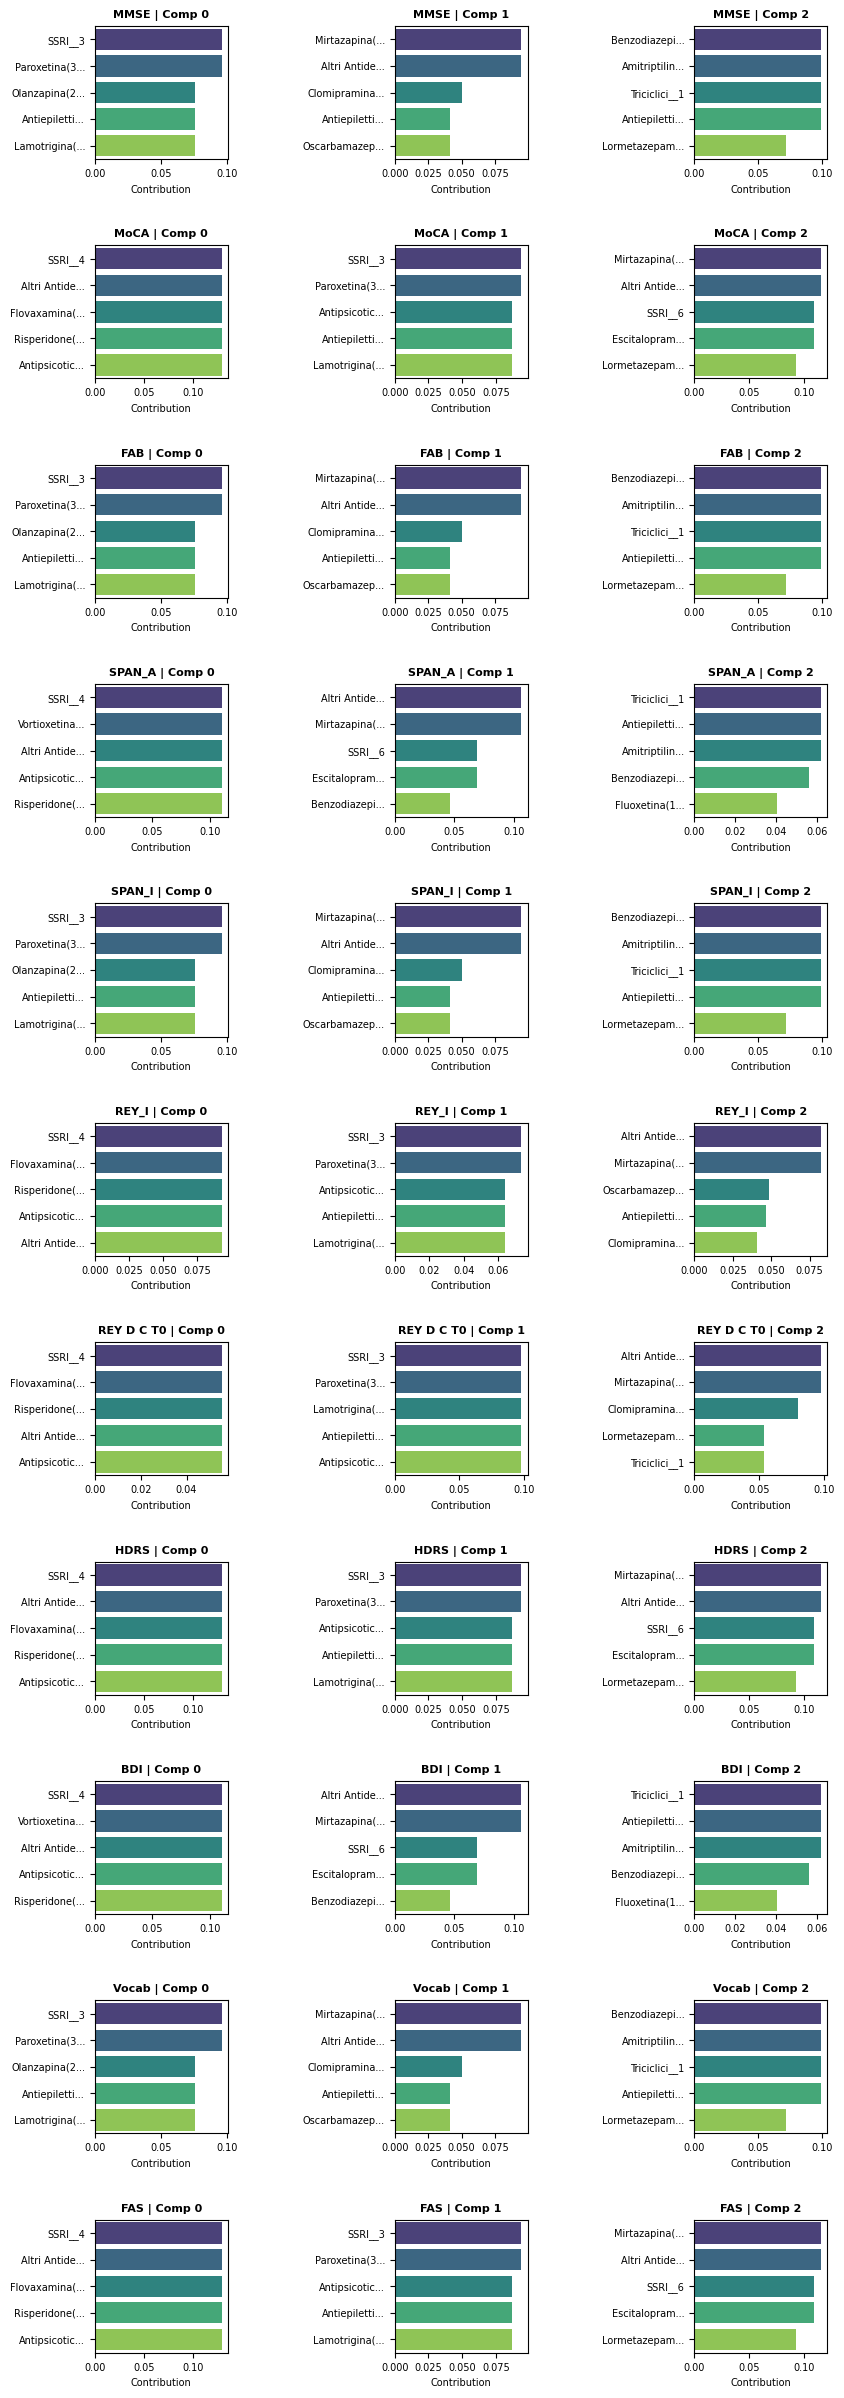

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Helper to truncate long feature names for paper-ready plots
def truncate_label(label, max_len=15):
    return str(label) if len(str(label)) <= max_len else str(label)[:max_len-3] + "..."

# --- 1. Ridge Coefficients Heatmap (5 Components) ---
# Width is set to be wider to accommodate 5 columns clearly
plt.figure(figsize=(12, 0.8 * len(target_names))) 

for i, target in enumerate(target_names):
    coefficients = coefficients_per_target[target]
    # Keep the first 5 components for coefficients
    non_zero_indices = np.where(coefficients != 0)[0][:5] 

    ax = plt.subplot(len(target_names), 1, i + 1)
    xticklabels = [f"C{j}" for j in non_zero_indices]
    
    sns.heatmap(
        coefficients[non_zero_indices].reshape(1, -1),
        annot=True,
        cmap="coolwarm",
        fmt=".2f",      
        xticklabels=xticklabels,
        yticklabels=[target],
        cbar=False, 
        annot_kws={"size": 8, "weight": "bold"} 
    )
    ax.set_title(f"Ridge Coefficients: {target}", fontsize=10, pad=5)
    ax.tick_params(axis='both', which='major', labelsize=8, length=0)

plt.tight_layout(pad=1.0)
plt.show()

# --- 2. Contribution Plots (3 Columns Only) ---
num_cols = 3 # Fixed to 3 for the paper layout
num_top_contributors = 5

# 8.5 to 10 inches is standard for a full-page width figure
fig_width = 9.0 
fig_height = 2.2 * len(target_names)

fig, axes = plt.subplots(
    len(target_names), 
    num_cols, 
    figsize=(fig_width, fig_height), 
    sharey=False 
)

# Handle cases where target_names or num_cols is 1 to maintain 2D indexing
axes = np.atleast_2d(axes)
if num_cols == 1 and len(target_names) > 1:
    axes = axes.T

for i, target in enumerate(target_names):
    contribution = mca_contributions_per_target[target]
    for j in range(num_cols):
        # Sort and isolate the specific component's top contributors
        top_data = contribution[j].sort_values(ascending=False).head(num_top_contributors)
        
        # Clean labels to prevent overlapping into adjacent subplots
        short_labels = [truncate_label(idx) for idx in top_data.index]
        
        sns.barplot(
            x=top_data.values,
            y=short_labels,
            ax=axes[i, j],
            palette='viridis',
            hue=short_labels,
            legend=False,
        )
        
        # Appearance Tweaks
        axes[i, j].set_title(f'{target} | Comp {j}', fontsize=8, fontweight='bold')
        axes[i, j].set_xlabel('Contribution', fontsize=7)
        axes[i, j].set_ylabel('', fontsize=0)
        
        # Only show ticks for features with bars
        axes[i, j].set_yticks(range(len(short_labels)))
        axes[i, j].set_yticklabels(short_labels, fontsize=7)
        axes[i, j].tick_params(axis='x', labelsize=7)
        
        # The "Squared" look
        axes[i, j].set_box_aspect(1) 

# w_pad=4.0 ensures the y-labels of column 2 and 3 don't touch column 1 and 2
plt.tight_layout(pad=1.5, w_pad=4.0, h_pad=2.5)
plt.show()

### Running a Ridge Regression model with Nested-Cross Validation (Robust) - BIPOLAR I

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
import prince

# Prepare variables for our predictive model
X_2 = t0_2
y_2 = pd.DataFrame(tdiff_2, columns=columns_2)
adjust_param = 1e-15

# fix one NaN in Span_A
y_2[pd.isnull(y_2)] = 0

# Initialize storage for best models (one per target)
best_models_per_target = {}
coefficients_per_target = {}
mca_contributions_per_target = {}

# Define the Ridge regression model
model = Ridge()

# Define the grid for searching the MCA components
param_grid = {
    'mca__n_components': [5, 15, 30],
    'model__alpha': [0.1, 1, 10]
}

outer_cv = KFold(n_splits=5, shuffle=True, random_state=44852523)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=73491241)

# Initialize storage for MAE and confidence intervals
mae_scores = []
mae_ci_lower = []
mae_ci_upper = []
target_names = []

# Loop through all targets (columns in y_1)
for idx, target in enumerate(y_2.columns):
    print(f"Processing Target {idx}: {target}")
    y_target = y_2[target]
    
    # Initialize variables to store the best model and evaluation scores
    best_model_for_target = None
    best_score = np.inf  # We will minimize the MSE
    
    # Storage for test scores for each fold
    test_scores_mae = []
    test_scores_r2 = []
    
    # Outer loop (for cross-validation)
    for train_idx, test_idx in outer_cv.split(X_2, y_target):
        X_train, X_test = X_2.iloc[train_idx], X_2.iloc[test_idx]
        y_train, y_test = y_target.iloc[train_idx], y_target.iloc[test_idx]
        
        # Define the pipeline: MCA -> Ridge regression model
        pipeline = Pipeline([
            ('mca', prince.MCA(
                n_iter=5000,
                copy=True,
                check_input=True,
                engine='sklearn',
                random_state=283434922)),
            ('model', model)
        ])

        # Inner cross-validation loop using GridSearchCV to tune hyperparameters
        grid_search = GridSearchCV(pipeline, param_grid, cv=inner_cv, scoring='neg_mean_squared_error', n_jobs=4)

        # Perform grid search with cross-validation on the training set
        grid_search.fit(X_train, y_train)
        
        # Get the best model from the grid search
        best_fold_model = grid_search.best_estimator_

        # Evaluate the model on the test fold and store scores
        y_pred = best_fold_model.predict(X_test)
        
        mae = mean_absolute_error(y_test, y_pred)
        r2 = np.corrcoef(y_test, y_pred)[0][1]**2
        #r2 = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred}).corr().iloc[0, 1] ** 2
        
        # Store the MAE for the current fold
        test_scores_mae.append(mae)
        test_scores_r2.append(r2)

        # Track the best model based on the lowest MSE
        if mae < best_score:
            best_score = mae
            best_model_for_target = best_fold_model
    
    # After all outer folds, store the best model for the current target
    best_models_per_target[target] = best_model_for_target

    # Extract the coefficients from the best model
    ridge_model = best_model_for_target.named_steps['model']
    coefficients_per_target[target] = ridge_model.coef_

    # Get best contribution to each component
    mca = best_model_for_target.named_steps['mca']
    mca_contributions_per_target[target] = mca.column_contributions_

    # Compute the mean and confidence intervals for MAE across all folds
    mean_mae = np.mean(test_scores_mae)
    mean_r2 = np.mean(test_scores_r2)
    ci_lower = np.percentile(test_scores_mae, 2.5)  # 95% confidence interval lower bound
    ci_upper = np.percentile(test_scores_mae, 97.5)  # 95% confidence interval upper bound
    
    # Store the results for plotting
    mae_scores.append(mean_mae)
    mae_ci_lower.append(ci_lower)
    mae_ci_upper.append(ci_upper)
    target_names.append(target)

    print(f"{target}: R2: {mean_r2}, MAE: {mean_mae}")

Processing Target 0: MMSE
MMSE: R2: 0.34691030433581777, MAE: 3.7595661276857606
Processing Target 1: MoCA
MoCA: R2: 0.5418094801299504, MAE: 2.737365572623432
Processing Target 2: FAB
FAB: R2: 0.215037101953665, MAE: 8.971129958212908
Processing Target 3: SPAN_A
SPAN_A: R2: 0.03956218422422389, MAE: 0.788253987244288
Processing Target 4: SPAN_I
SPAN_I: R2: 0.060073885732418605, MAE: 1.0876902034260838
Processing Target 5: REY_I
REY_I: R2: 0.13786364489189448, MAE: 8.106166913614178
Processing Target 6: REY D C T0
REY D C T0: R2: 0.2973347770347108, MAE: 2.5138978276595343
Processing Target 7: HDRS
HDRS: R2: 0.27055216999086, MAE: 8.663860792376804
Processing Target 8: BDI
BDI: R2: 0.5190570721482927, MAE: 13.429801258379456
Processing Target 9: Vocab
Vocab: R2: 0.0992445819037738, MAE: 1.8130358103125623
Processing Target 10: FAS
FAS: R2: 0.17660628670535536, MAE: 8.225657030003083


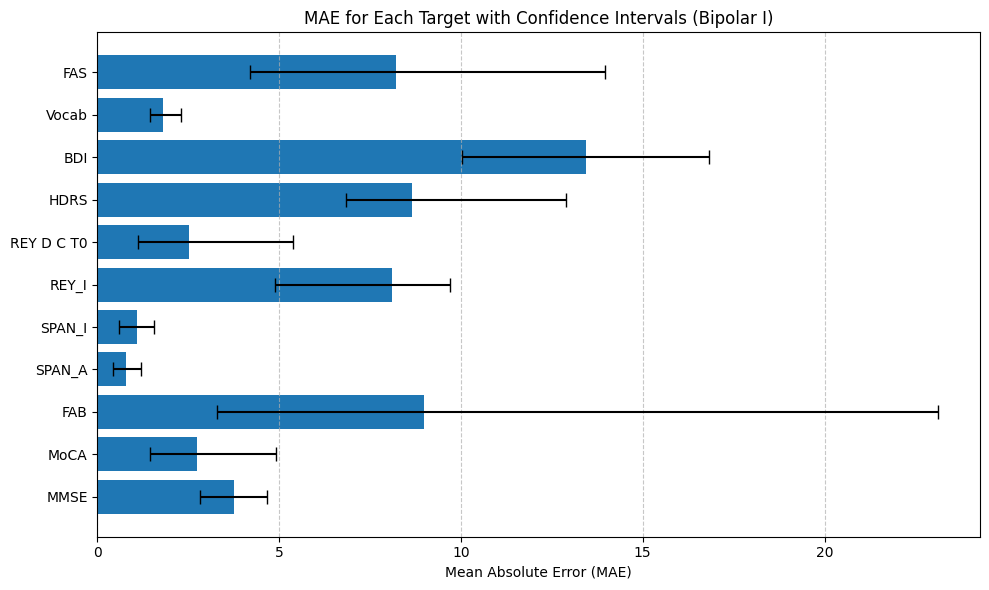

In [15]:
# Plotting the MAE with confidence intervals
plt.figure(figsize=(10, 6))
plt.barh(target_names, mae_scores, xerr=[np.array(mae_scores) - np.array(mae_ci_lower), np.array(mae_ci_upper) - np.array(mae_scores)], capsize=5)
plt.xlabel('Mean Absolute Error (MAE)')
plt.title('MAE for Each Target with Confidence Intervals (Bipolar I)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [16]:
best_models_per_target # best overall models have 5-15 components;

{'MMSE': Pipeline(steps=[('mca',
                  MCA(n_components=15, n_iter=5000, random_state=283434922)),
                 ('model', Ridge(alpha=1))]),
 'MoCA': Pipeline(steps=[('mca',
                  MCA(n_components=5, n_iter=5000, random_state=283434922)),
                 ('model', Ridge(alpha=10))]),
 'FAB': Pipeline(steps=[('mca',
                  MCA(n_components=5, n_iter=5000, random_state=283434922)),
                 ('model', Ridge(alpha=10))]),
 'SPAN_A': Pipeline(steps=[('mca',
                  MCA(n_components=5, n_iter=5000, random_state=283434922)),
                 ('model', Ridge(alpha=10))]),
 'SPAN_I': Pipeline(steps=[('mca',
                  MCA(n_components=15, n_iter=5000, random_state=283434922)),
                 ('model', Ridge(alpha=1))]),
 'REY_I': Pipeline(steps=[('mca',
                  MCA(n_components=5, n_iter=5000, random_state=283434922)),
                 ('model', Ridge(alpha=0.1))]),
 'REY D C T0': Pipeline(steps=[('mca',
              

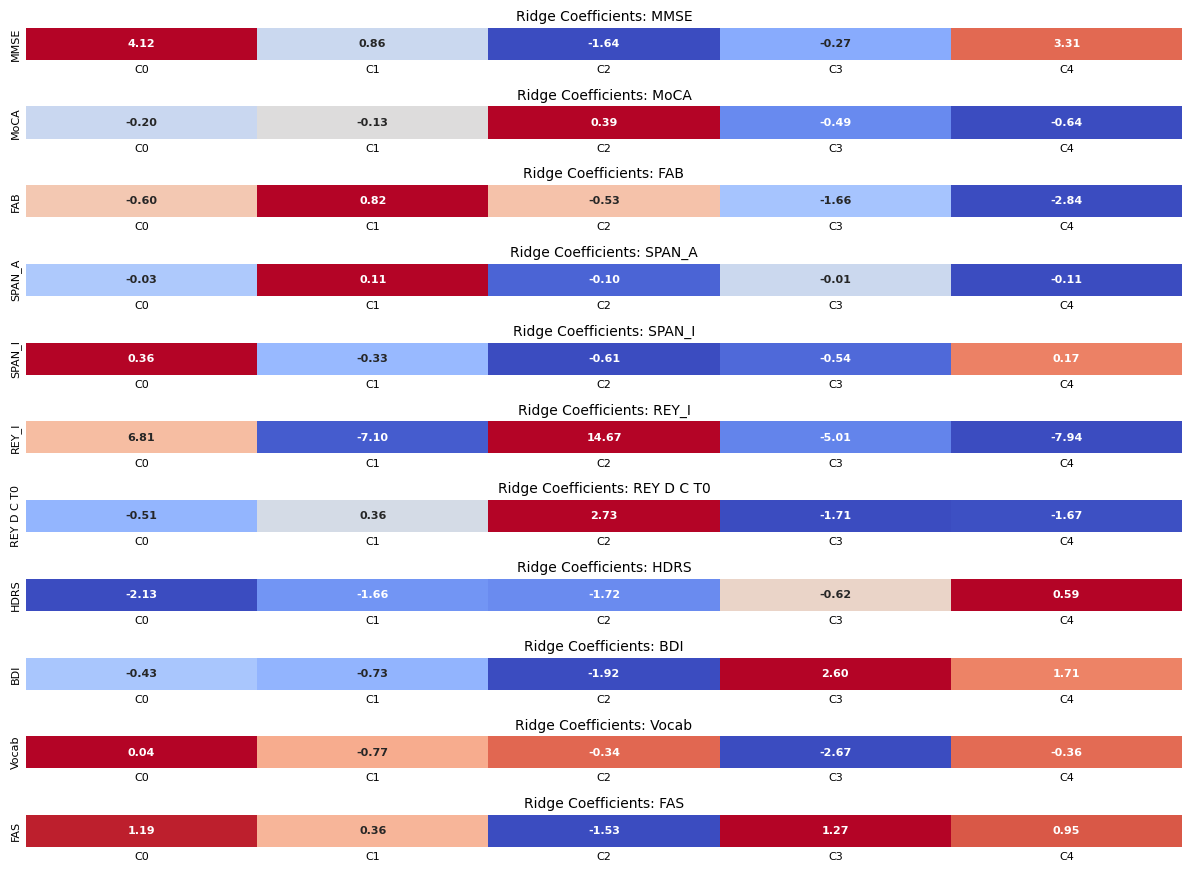

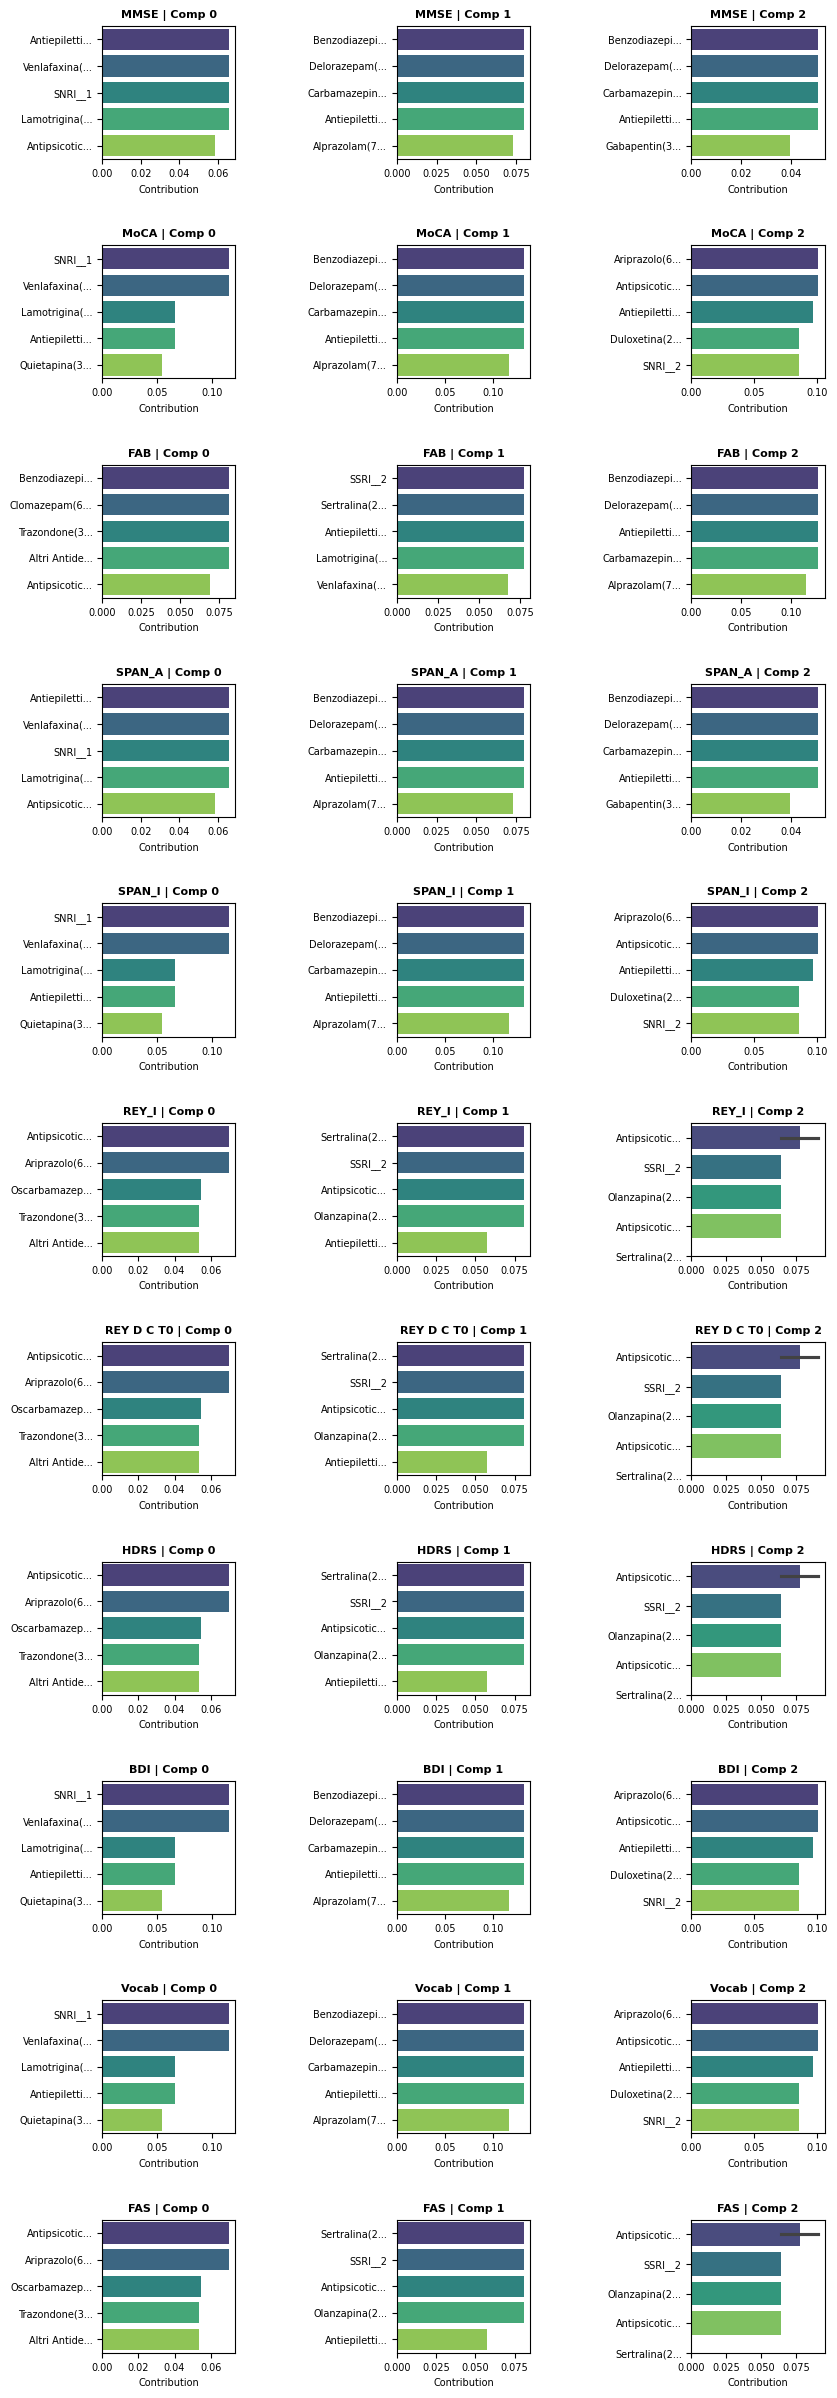

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Helper to truncate long feature names for paper-ready plots
def truncate_label(label, max_len=15):
    return str(label) if len(str(label)) <= max_len else str(label)[:max_len-3] + "..."

# --- 1. Ridge Coefficients Heatmap (5 Components) ---
# Width is set to be wider to accommodate 5 columns clearly
plt.figure(figsize=(12, 0.8 * len(target_names))) 

for i, target in enumerate(target_names):
    coefficients = coefficients_per_target[target]
    # Keep the first 5 components for coefficients
    non_zero_indices = np.where(coefficients != 0)[0][:5] 

    ax = plt.subplot(len(target_names), 1, i + 1)
    xticklabels = [f"C{j}" for j in non_zero_indices]
    
    sns.heatmap(
        coefficients[non_zero_indices].reshape(1, -1),
        annot=True,
        cmap="coolwarm",
        fmt=".2f",      
        xticklabels=xticklabels,
        yticklabels=[target],
        cbar=False, 
        annot_kws={"size": 8, "weight": "bold"} 
    )
    ax.set_title(f"Ridge Coefficients: {target}", fontsize=10, pad=5)
    ax.tick_params(axis='both', which='major', labelsize=8, length=0)

plt.tight_layout(pad=1.0)
plt.show()

# --- 2. Contribution Plots (3 Columns Only) ---
num_cols = 3 # Fixed to 3 for the paper layout
num_top_contributors = 5

# 8.5 to 10 inches is standard for a full-page width figure
fig_width = 9.0 
fig_height = 2.2 * len(target_names)

fig, axes = plt.subplots(
    len(target_names), 
    num_cols, 
    figsize=(fig_width, fig_height), 
    sharey=False 
)

# Handle cases where target_names or num_cols is 1 to maintain 2D indexing
axes = np.atleast_2d(axes)
if num_cols == 1 and len(target_names) > 1:
    axes = axes.T

for i, target in enumerate(target_names):
    contribution = mca_contributions_per_target[target]
    for j in range(num_cols):
        # Sort and isolate the specific component's top contributors
        top_data = contribution[j].sort_values(ascending=False).head(num_top_contributors)
        
        # Clean labels to prevent overlapping into adjacent subplots
        short_labels = [truncate_label(idx) for idx in top_data.index]
        
        sns.barplot(
            x=top_data.values,
            y=short_labels,
            ax=axes[i, j],
            palette='viridis',
            hue=short_labels,
            legend=False,
        )
        
        # Appearance Tweaks
        axes[i, j].set_title(f'{target} | Comp {j}', fontsize=8, fontweight='bold')
        axes[i, j].set_xlabel('Contribution', fontsize=7)
        axes[i, j].set_ylabel('', fontsize=0)
        
        # Only show ticks for features with bars
        axes[i, j].set_yticks(range(len(short_labels)))
        axes[i, j].set_yticklabels(short_labels, fontsize=7)
        axes[i, j].tick_params(axis='x', labelsize=7)
        
        # The "Squared" look
        axes[i, j].set_box_aspect(1) 

# w_pad=4.0 ensures the y-labels of column 2 and 3 don't touch column 1 and 2
plt.tight_layout(pad=1.5, w_pad=4.0, h_pad=2.5)
plt.show()